# Loading Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load both datasets
df_label = pd.read_csv('../data/processed/laptop_label_encoded.csv')
df_onehot = pd.read_csv('../data/processed/laptop_onehot_encoded.csv')

print(f"Label encoded shape: {df_label.shape}")
print(f"One-hot encoded shape: {df_onehot.shape}")

# Verify target variable
print(f"\nLog_Price stats:")
print(df_label['Log_Price'].describe().round(2))

Label encoded shape: (1020, 22)
One-hot encoded shape: (1020, 63)

Log_Price stats:
count    1020.00
mean       11.10
std         0.63
min         8.99
25%        10.69
50%        11.06
75%        11.46
max        13.30
Name: Log_Price, dtype: float64


# Checking for any differences before processing for modeling

In [2]:
#checking for dtypes
print("\n Dtype Check")
print("DF Label")
print(df_label.dtypes)


 Dtype Check
DF Label
Brand                    int64
Price                    int64
Processor_brand          int64
Threads                float64
RAM_type                 int64
Storage_type             int64
Graphics_brand           int64
Graphics_integreted      int64
Touch_screen             int64
Operating_system         int64
Log_Price              float64
GPU_tier                 int64
RAM_tier                 int64
Storage_tier             int64
Processor_gen_tier       int64
Display_tier             int64
ppi_tier                 int64
is_gaming                int64
brand_tier               int64
proc_brand_tier          int64
performance_score      float64
display_quality          int64
dtype: object


In [3]:
#checking for dtypes
print("\n Dtype Check")
print("DF onehot")
print(df_onehot.dtypes)


 Dtype Check
DF onehot
Price                         int64
Threads                     float64
Graphics_integreted           int64
Touch_screen                  int64
Log_Price                   float64
                             ...   
brand_tier_Mid                 bool
brand_tier_Mid_High            bool
brand_tier_Premium             bool
proc_brand_tier_Premium        bool
proc_brand_tier_Standard       bool
Length: 63, dtype: object


In [4]:
#checking for dtypes
print("\n Dtype Check")
obj_label = df_label.select_dtypes(include='object').columns.tolist()
obj_onehot = df_onehot.select_dtypes(include='object').columns.tolist()
print(f"Object cols in label encoded: {obj_label if obj_label else 'None'}")
print(f"Object cols in one-hot encoded: {obj_onehot if obj_onehot else 'None'}")


 Dtype Check
Object cols in label encoded: None
Object cols in one-hot encoded: None


In [5]:
tier_map = {'Budget': 0, 'Standard': 1, 'Premium': 2}
df_label['proc_brand_tier'] = df_label['proc_brand_tier'].map(tier_map)

In [6]:
#verifying
print(df_label['proc_brand_tier'].dtype)
print(df_label['proc_brand_tier'].unique())

float64
[nan]


In [7]:
# preprocessing for modeling
# checking for nulls
print("Label encoded nulls:", df_label.isnull().sum().sum())
print("One-hot encoded nulls:", df_onehot.isnull().sum().sum())

Label encoded nulls: 1020
One-hot encoded nulls: 0


In [8]:
#target column in the data
print("'Log_Price' in label encoded:", 'Log_Price' in df_label.columns)
print("'Log_Price' in one-hot encoded:", 'Log_Price' in df_onehot.columns)

'Log_Price' in label encoded: True
'Log_Price' in one-hot encoded: True


# Modeling

In [9]:
# Label encoded ->  for Random Forest & XGBoost
X_label = df_label.drop(columns=['Log_Price','Price'])
y = df_label['Log_Price']

# One-hot encoded -> for Linear Regression
X_onehot = df_onehot.drop(columns=['Log_Price','Price'])

# Same random_state so all models train/test on identical rows
X_train_label, X_test_label, y_train, y_test = train_test_split(
    X_label, y, test_size=0.2, random_state=42
)

X_train_onehot, X_test_onehot, _, _ = train_test_split(
    X_onehot, y, test_size=0.2, random_state=42
)

print(f"Train size: {X_train_label.shape[0]} | Test size: {X_test_label.shape[0]}")
print(f"Label encoded features:  {X_train_label.shape[1]}")
print(f"One-hot encoded features: {X_train_onehot.shape[1]}")

Train size: 816 | Test size: 204
Label encoded features:  20
One-hot encoded features: 61


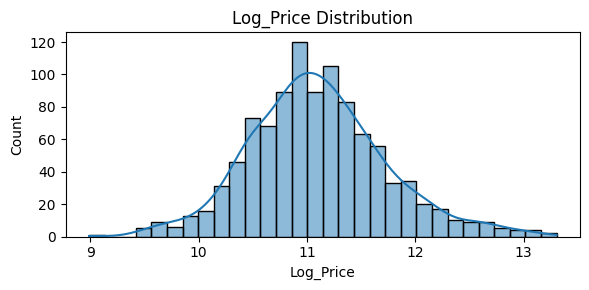

In [10]:
#checking target variable 
plt.figure(figsize=(6, 3))
sns.histplot(y, kde=True, bins=30)
plt.title("Log_Price Distribution")
plt.xlabel("Log_Price")
plt.tight_layout()
plt.show()

# Linear Regression

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Pipeline: scale → fit
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train_onehot, y_train)
y_pred_lr = lr_pipeline.predict(X_test_onehot)

# Metrics
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
r2_lr   = r2_score(y_test, y_pred_lr)

print("Linear Regression")
print(f"RMSE : {rmse_lr:.4f}")
print(f"MAE  : {mae_lr:.4f}")
print(f"R²   : {r2_lr:.4f}")

Linear Regression
RMSE : 0.2108
MAE  : 0.1497
R²   : 0.8726


## Linear Regression -- Results

**R2 = 0.87** -- The model explains 87% of price variation from specs alone. Not bad for a baseline with zero tuning.

**RMSE = 0.2108** -- Translates to roughly 23% price error in actual price. On a Rs 50,000 laptop, that's approximately Rs 11,500 off.

**MAE = 0.1497** -- On average, predictions are about 15% off in log terms. A forgiving metric since it doesn't over-penalize big mistakes.

Tree models should push these numbers higher. Linear Regression can't capture non-linear spec-price relationships.

# Random Forest

In [12]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_label, y_train)
y_pred_rf = rf.predict(X_test_label)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
r2_rf   = r2_score(y_test, y_pred_rf)

print("Random Forest")
print(f"RMSE : {rmse_rf:.4f}")
print(f"MAE  : {mae_rf:.4f}")
print(f"R²   : {r2_rf:.4f}")

Random Forest
RMSE : 0.2249
MAE  : 0.1462
R²   : 0.8550


## Random Forest - Results

**R2 = 0.855** - Explains 85.5% of price variation. Surprisingly slightly below Linear Regression, which is unusual for a tree model.

**RMSE = 0.2249** - Roughly 25% price error. On a Rs 50,000 laptop, that's approximately Rs 12,500 off - a bit worse than Linear Regression.

**MAE = 0.1450** - Average prediction is about 14.5% off in log terms. Marginally better than LR on MAE though.

Hyperparameter tuning should improve this - default 100 trees with no depth tuning is a weak starting point for Random Forest.

## Random Forest Hyper parameter tuning

In [13]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2']
}

rf_tuned = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

rf_tuned.fit(X_train_label, y_train)

print("Best params:", rf_tuned.best_params_)

# Evaluate best model
y_pred_rf_tuned = rf_tuned.predict(X_test_label)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf_tuned))
mae_rf  = mean_absolute_error(y_test, y_pred_rf_tuned)
r2_rf   = r2_score(y_test, y_pred_rf_tuned)

print("\nRandom Forest (Tuned)")
print(f"RMSE : {rmse_rf:.4f}")
print(f"MAE  : {mae_rf:.4f}")
print(f"R2   : {r2_rf:.4f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best params: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 300}

Random Forest (Tuned)
RMSE : 0.2174
MAE  : 0.1440
R2   : 0.8645


#### Even the tuned RF model is not performing as good as Linear regression even if a lot features exist, I am going to investigate this further

In [14]:
#Check feature importances
importances = pd.Series(rf_tuned.best_estimator_.feature_importances_, index=X_train_label.columns)
importances.sort_values(ascending=False).head(10)

Threads              0.163429
display_quality      0.149559
performance_score    0.114669
RAM_tier             0.107300
GPU_tier             0.091874
Storage_tier         0.085176
is_gaming            0.038313
ppi_tier             0.037262
RAM_type             0.035728
brand_tier           0.035613
dtype: float64

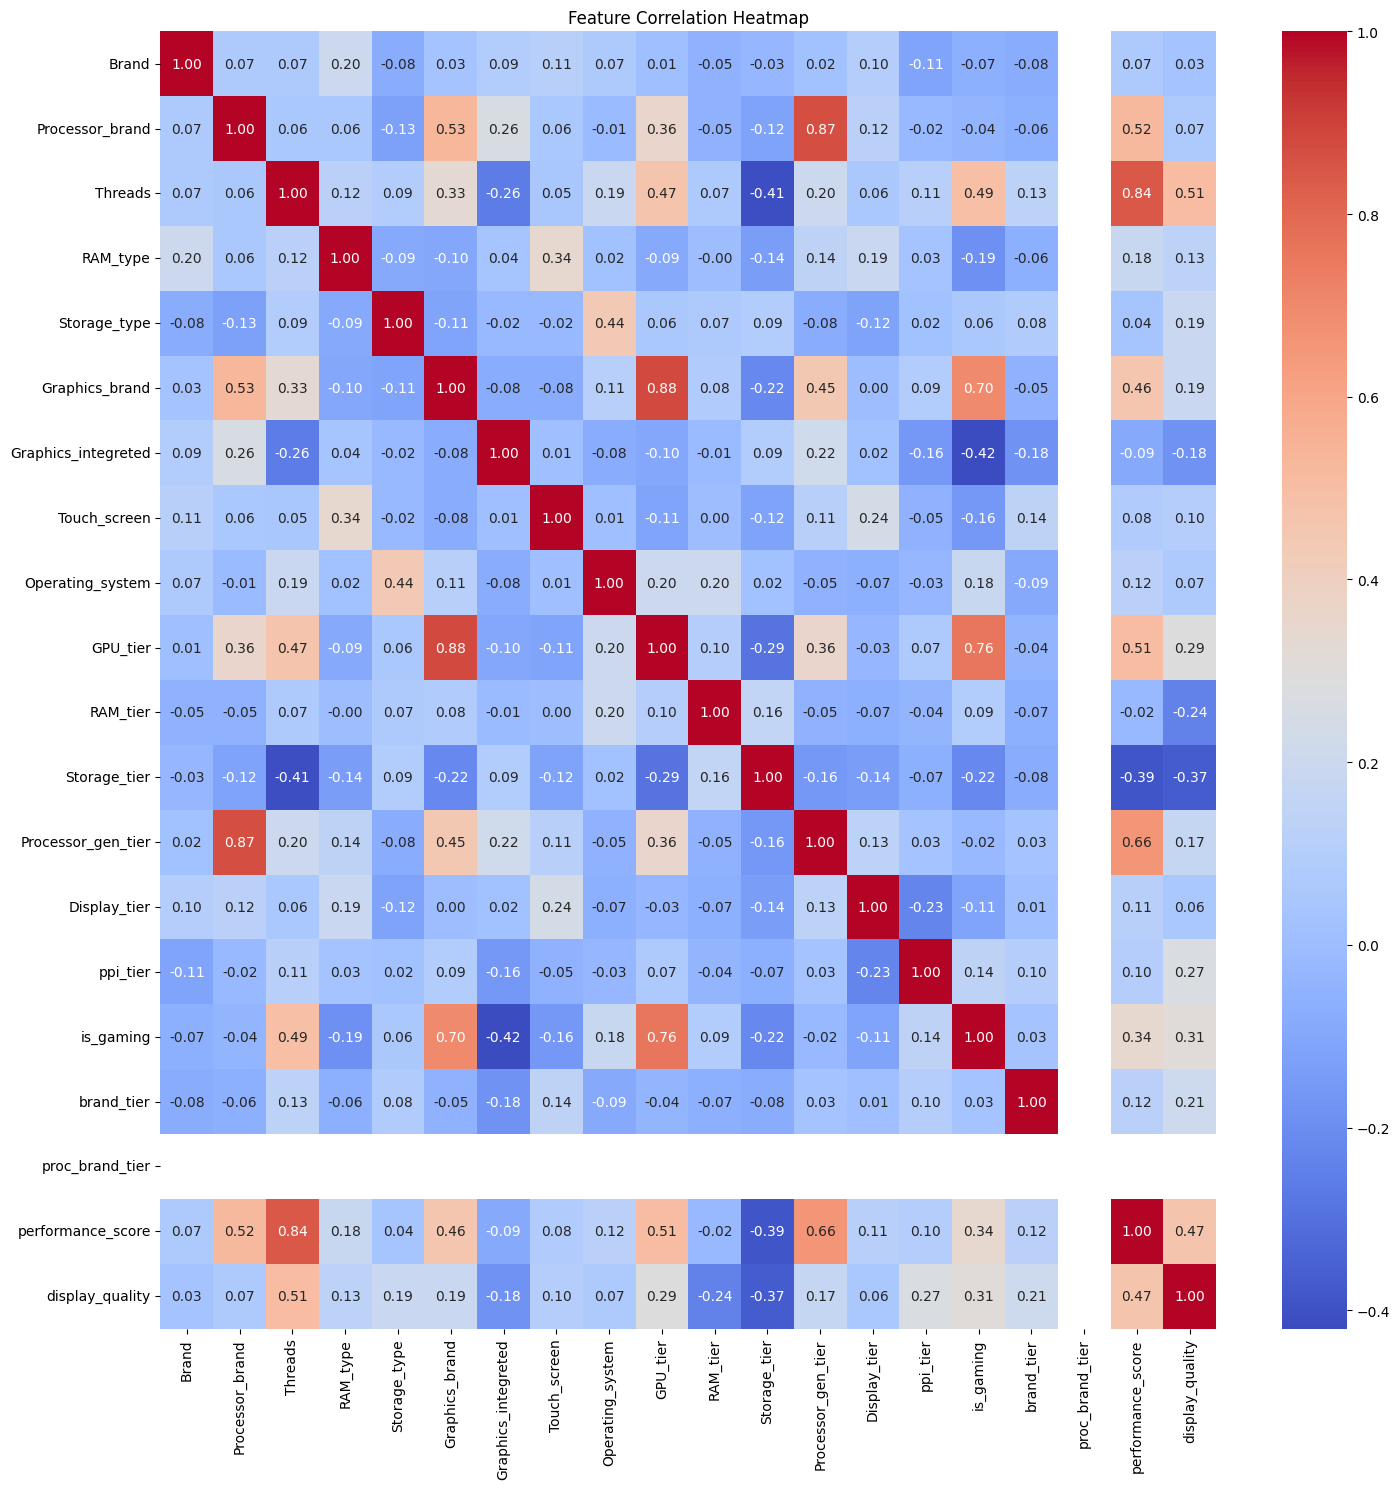

In [15]:
plt.figure(figsize=(15,15))
sns.heatmap(X_train_label.corr().round(2), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [16]:
corr_matrix = X_train_label.corr().abs()

# Get upper triangle only to avoid duplicates
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Filter pairs above 0.8
high_corr = [(col, row, upper.loc[row, col]) 
             for col in upper.columns 
             for row in upper.index 
             if upper.loc[row, col] > 0.8]

high_corr_df = pd.DataFrame(high_corr, columns=['Feature 1', 'Feature 2', 'Correlation'])
print(high_corr_df.sort_values('Correlation', ascending=False).to_string())

            Feature 1        Feature 2  Correlation
0            GPU_tier   Graphics_brand     0.876227
1  Processor_gen_tier  Processor_brand     0.871514
2   performance_score          Threads     0.843220


#### There are a lot of columns which are correlated to each other causing multi colinearity

I am going to drop 1 column per each of the multi correlated features

**Decisions:**

- GPU_tier is more informative (captures RTX tier, Integrated etc.) -> dropping Graphics_brand
- gen tier is more granular -> dropping Processor_brand (which also helps for proc_brand_tier)
- performance_score already encodes threads -> dropping Threads
- Processor_gen_tier is more granular -> dropping proc_brand_tier

**Columns dropped:** Graphics_brand, Processor_brand, Threads, proc_brand_tier


# Re running the models

In [17]:
drop_cols = ['Graphics_brand', 'Processor_brand', 'Threads', 'proc_brand_tier']

X_train_label = X_train_label.drop(columns=drop_cols)
X_test_label  = X_test_label.drop(columns=drop_cols)

# For onehot, only drop cols that exist
drop_onehot = [c for c in drop_cols if c in X_train_onehot.columns]
X_train_onehot = X_train_onehot.drop(columns=drop_onehot)
X_test_onehot  = X_test_onehot.drop(columns=drop_onehot)

print(f"Label encoded features: {X_train_label.shape[1]}")
print(f"One-hot encoded features: {X_train_onehot.shape[1]}")

Label encoded features: 16
One-hot encoded features: 60


In [18]:
# re running all the models
# Linear Regression
lr_pipeline.fit(X_train_onehot, y_train)
y_pred_lr = lr_pipeline.predict(X_test_onehot)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
r2_lr   = r2_score(y_test, y_pred_lr)
print("Linear Regression")
print(f"RMSE : {rmse_lr:.4f}")
print(f"MAE  : {mae_lr:.4f}")
print(f"R2   : {r2_lr:.4f}")


Linear Regression
RMSE : 0.2164
MAE  : 0.1526
R2   : 0.8657


In [19]:
rf_retune = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

rf_retune.fit(X_train_label, y_train)
print("Best params:", rf_retune.best_params_)

y_pred_rf = rf_retune.predict(X_test_label)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
r2_rf   = r2_score(y_test, y_pred_rf)
print(f"\nRMSE : {rmse_rf:.4f}")
print(f"MAE  : {mae_rf:.4f}")
print(f"R2   : {r2_rf:.4f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best params: {'max_depth': 20, 'max_features': 'log2', 'min_samples_split': 2, 'n_estimators': 300}

RMSE : 0.2202
MAE  : 0.1492
R2   : 0.8610


In [20]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
xgb.fit(X_train_label, y_train)
y_pred_xgb = xgb.predict(X_test_label)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb   = r2_score(y_test, y_pred_xgb)

print("XGBoost")
print(f"RMSE : {rmse_xgb:.4f}")
print(f"MAE  : {mae_xgb:.4f}")
print(f"R2   : {r2_xgb:.4f}")

XGBoost
RMSE : 0.2250
MAE  : 0.1493
R2   : 0.8549


In [21]:
from sklearn.model_selection import GridSearchCV

xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0]
}

xgb_tuned = GridSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1),
    xgb_param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

xgb_tuned.fit(X_train_label, y_train)
print("Best params:", xgb_tuned.best_params_)

y_pred_xgb = xgb_tuned.predict(X_test_label)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb   = r2_score(y_test, y_pred_xgb)

print(f"\nRMSE : {rmse_xgb:.4f}")
print(f"MAE  : {mae_xgb:.4f}")
print(f"R2   : {r2_xgb:.4f}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.8}

RMSE : 0.2125
MAE  : 0.1418
R2   : 0.8706


In [22]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest (Tuned)', 'XGBoost (Tuned)'],
    'RMSE': [rmse_lr, rmse_rf, rmse_xgb],
    'MAE': [mae_lr, mae_rf, mae_xgb],
    'R2': [r2_lr, r2_rf, r2_xgb]
})

results = results.sort_values('R2', ascending=False).reset_index(drop=True)
print(results.round(4).to_string(index=False))

                Model   RMSE    MAE     R2
      XGBoost (Tuned) 0.2125 0.1418 0.8706
    Linear Regression 0.2164 0.1526 0.8657
Random Forest (Tuned) 0.2202 0.1492 0.8610


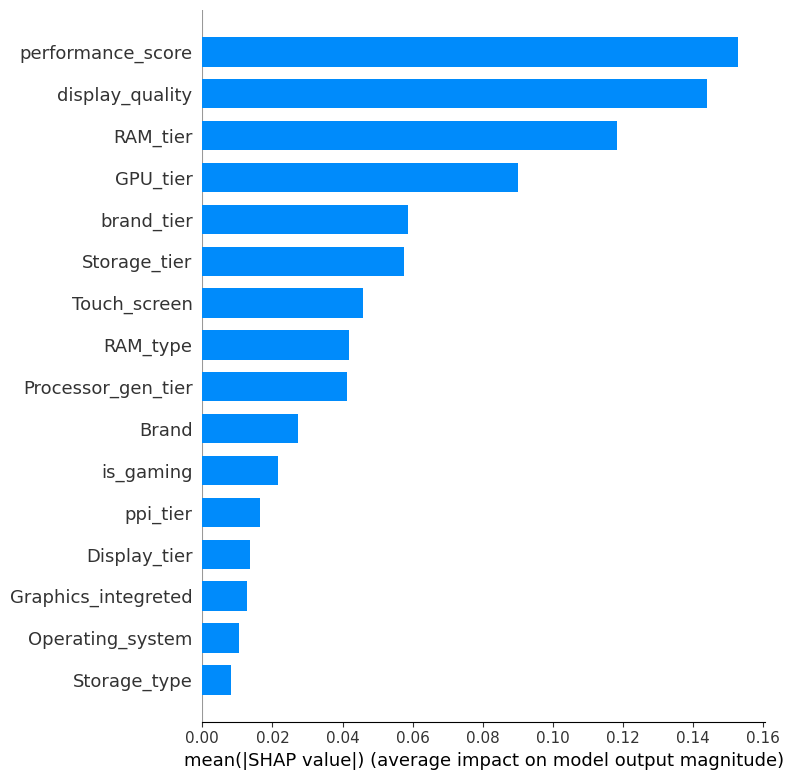

In [23]:
import shap

explainer = shap.TreeExplainer(xgb_tuned.best_estimator_)
shap_values = explainer.shap_values(X_test_label)

# Summary plot
shap.summary_plot(shap_values, X_test_label, plot_type='bar')

**Top drivers:**
- **performance_score & display_quality** dominate — together they account for nearly 30% of prediction impact. engineered features are dominating
- **RAM_tier & GPU_tier** are next — these are the two specs consumers care most about.
- **brand_tier & Storage_tier** — moderate influence, brand premium is real but not overwhelming.

**Low signal features:**
- `Display_tier`, `Graphics_integreted`, `Operating_system`, `Storage_type` — barely moving the needle. These could be dropped in a future iteration.

This confirms that my feature engineering was solid. 

In [24]:
#1. Get predictions on full dataset 
X_full = df_label.drop(columns=['Log_Price', 'Price'] + drop_cols)
y_full = df_label['Log_Price']

y_pred_full = xgb_tuned.predict(X_full)

#2. Compute residuals (actual - predicted) in log scale
residuals = y_full.values - y_pred_full

# Convert to percentage difference in original price scale
# e.g. residual of +0.2 means actual price is ~22% higher than predicted
price_diff_pct = (np.exp(residuals) - 1) * 100

#3. Build fairness dataframe 
fairness_df = pd.DataFrame({
    'Actual_Log_Price': y_full.values,
    'Predicted_Log_Price': y_pred_full,
    'Residual': residuals,
    'Price_Diff_Pct': price_diff_pct
})

#4. Set thresholds and flag anomalies 
# Using 1 std dev as threshold
threshold = fairness_df['Price_Diff_Pct'].std()
print(f"Threshold (1 std dev): {threshold:.2f}%")

fairness_df['Fairness_Flag'] = 'Fair'
fairness_df.loc[fairness_df['Price_Diff_Pct'] >  threshold, 'Fairness_Flag'] = 'Overpriced'
fairness_df.loc[fairness_df['Price_Diff_Pct'] < -threshold, 'Fairness_Flag'] = 'Underpriced'

#5. Summary 
print("\nFairness Flag Distribution:")
print(fairness_df['Fairness_Flag'].value_counts())

print("\nPrice_Diff_Pct stats:")
print(fairness_df['Price_Diff_Pct'].describe().round(2))

Threshold (1 std dev): 15.45%

Fairness Flag Distribution:
Fairness_Flag
Fair           879
Overpriced      87
Underpriced     54
Name: count, dtype: int64

Price_Diff_Pct stats:
count    1020.00
mean        1.28
std        15.45
min       -46.94
25%        -5.98
50%        -0.37
75%         5.54
max       213.49
Name: Price_Diff_Pct, dtype: float64


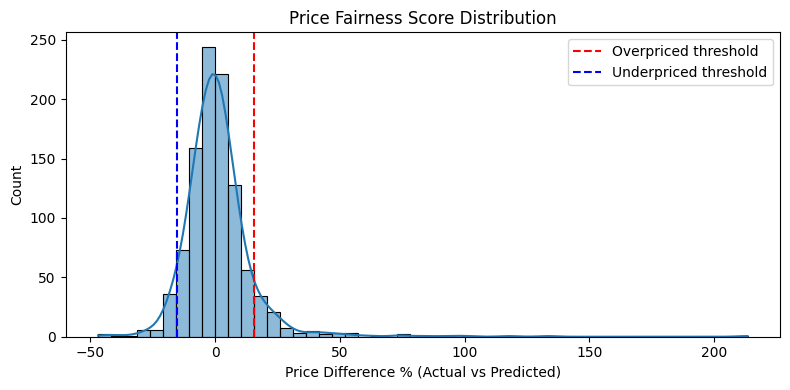

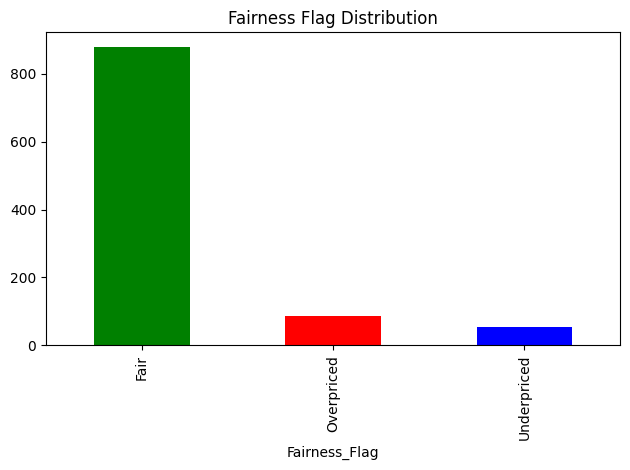

In [25]:
fairness_df['Actual_Price_INR'] = np.exp(fairness_df['Actual_Log_Price'])
fairness_df['Predicted_Price_INR'] = np.exp(fairness_df['Predicted_Log_Price'])

# Distribution of Price_Diff_Pct
plt.figure(figsize=(8, 4))
sns.histplot(fairness_df['Price_Diff_Pct'], bins=50, kde=True)
plt.axvline(threshold, color='red', linestyle='--', label='Overpriced threshold')
plt.axvline(-threshold, color='blue', linestyle='--', label='Underpriced threshold')
plt.title('Price Fairness Score Distribution')
plt.xlabel('Price Difference % (Actual vs Predicted)')
plt.legend()
plt.tight_layout()
plt.show()

# Flag distribution
fairness_df['Fairness_Flag'].value_counts().plot(kind='bar', color=['green', 'red', 'blue'])
plt.title('Fairness Flag Distribution')
plt.tight_layout()
plt.show()

In [26]:
fairness_df.to_csv('../data/processed/price_fairness_scores.csv', index=False)
print("Saved!")

Saved!


In [27]:
print(X_train_label.columns.tolist())

['Brand', 'RAM_type', 'Storage_type', 'Graphics_integreted', 'Touch_screen', 'Operating_system', 'GPU_tier', 'RAM_tier', 'Storage_tier', 'Processor_gen_tier', 'Display_tier', 'ppi_tier', 'is_gaming', 'brand_tier', 'performance_score', 'display_quality']


In [28]:
import joblib
joblib.dump(xgb_tuned.best_estimator_, 'xgb_tuned_model.pkl')

['xgb_tuned_model.pkl']

In [29]:
import joblib
joblib.dump(xgb_tuned.best_estimator_, '../streamlit_app/xgb_tuned_model.pkl')
print("Model saved!")

Model saved!
